### Plot for thesis introduction 

In [2]:
import rasterio as rio 
from rasterio.plot import show
import matplotlib.pyplot as plt

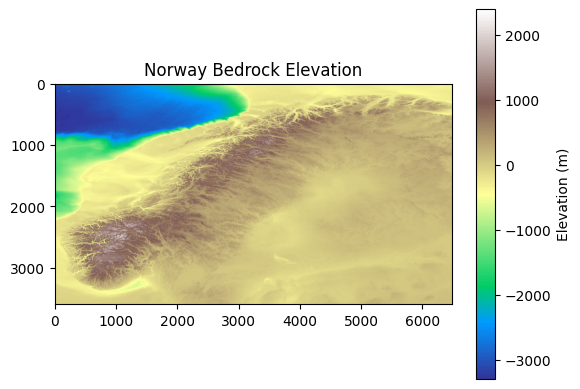

In [ ]:
tiff_path = r"C:\Users\danis\Desktop\Danish\Norway Plot Data\exportImage.tiff"

with rio.open(tiff_path) as src:
    bedrock = src.read(1)         # read first band 
    extent = src.bounds           # for plotting later
    transform = src.transform
    crs = src.crs                 # coordinate reference system

# Optional preview
plt.imshow(bedrock, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Norway Bedrock Elevation")
plt.show()

In [9]:
#for plotting on map
glacier_names = [
    "Ålfotbreen", "Austdalsbreen", "Engabreen", "Gråfjellsbrea",
    "Gråsubreen", "Hansebreen", "Hellstugubreen", "Langfjordjøkelen",
    "Nigardsbreen", "Rembesdalskåka", "Storbreen"
]

glacier_labels = [
    "Ålf", "Aus", "Eng", "Grå",
    "Grås", "Han", "Hell", "Lan",
    "Nig", "Rem", "Sto"
]

# Corresponding latitudes and longitudes
glacier_lats = [61.75, 61.65, 66.65, 60.00, 61.66, 61.85, 61.57, 70.17, 61.80, 60.54, 61.60]
glacier_lons = [5.65, 7.25, 13.85, 6.25, 8.60, 5.75, 8.44, 21.75, 7.13, 7.37, 8.00]

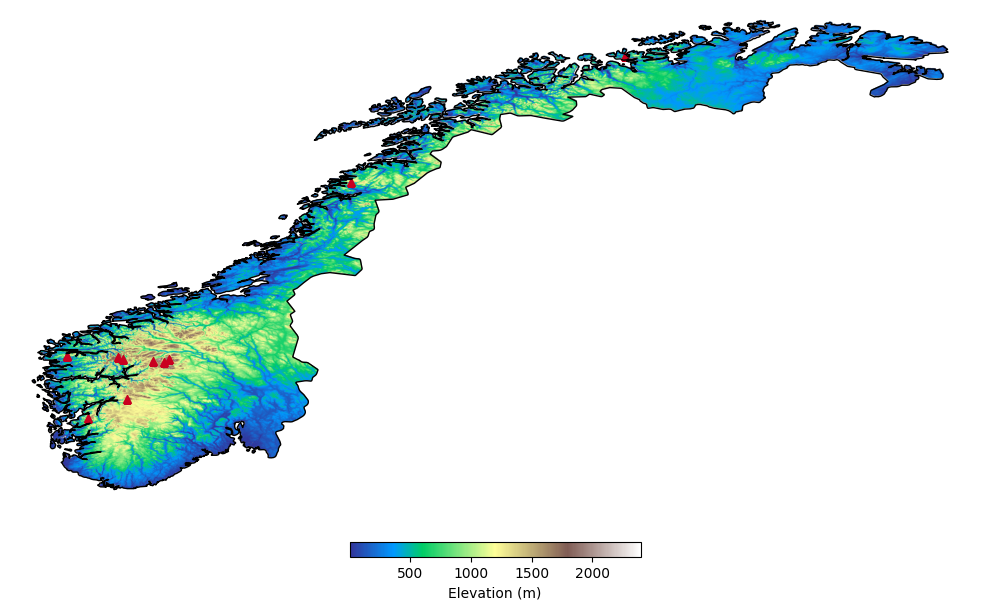

In [60]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import geopandas as gpd

# Load world shapefile and filter for Norway
gdf = gpd.read_file(r"C:\Users\danis\Desktop\Danish\Norway Plot Data\ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp")
norway = gdf[gdf["ADMIN"] == "Norway"]
norway_extent = [4, 32, 57.5, 71.5]


fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={'projection': ccrs.PlateCarree()})
img = ax.imshow(bedrock, cmap=plt.get_cmap("terrain"), extent=extent,
                transform=ccrs.PlateCarree(), zorder=0)
ax.plot(glacier_lons, glacier_lats, marker='^', color='#ca0020', 
        linestyle='none', transform=ccrs.PlateCarree())

#ax.coastlines(resolution='10m') 
#ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
norway.boundary.plot(ax=ax, color="black", linewidth=1, transform=ccrs.PlateCarree())
ax.set_extent(norway_extent, crs=ccrs.PlateCarree())

cb = plt.colorbar(img, ax=ax, orientation="horizontal", shrink=0.3, pad=0.03, aspect=20)
cb.set_label("Elevation (m)")

#ax.set_title("Norway Topography")
ax.axis("off")
plt.tight_layout()
#plt.savefig('topography_norway2.png', dpi=800, bbox_inches='tight')
plt.show()

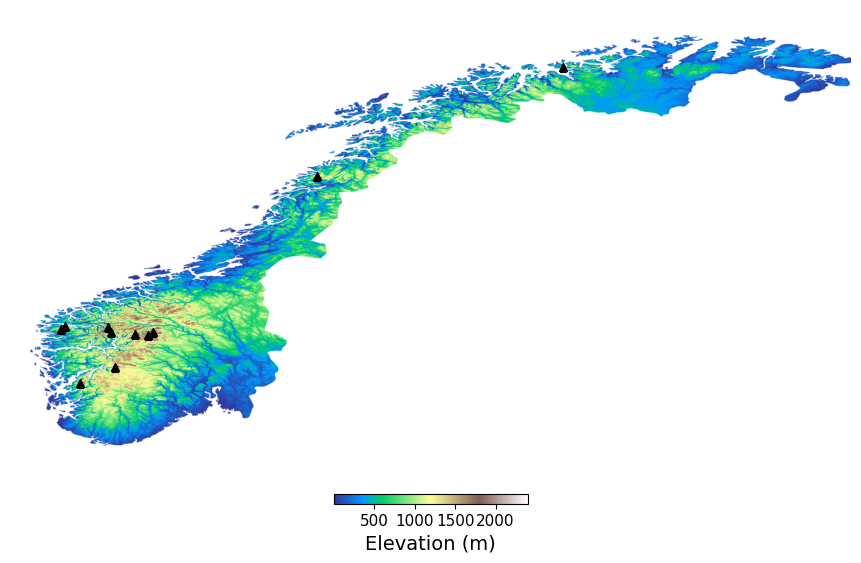

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask
import numpy as np

# Load Norway shape
gdf = gpd.read_file(r"C:\Users\danis\Desktop\Danish\Norway Plot Data\ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp")
norway = gdf[gdf["ADMIN"] == "Norway"]
#norway = norway.to_crs("EPSG:4326")

# Load and crop raster
with rio.open(r"C:\Users\danis\Desktop\Danish\Norway Plot Data\exportImage.tiff") as src:
    out_image, out_transform = mask(src, norway.geometry, crop=True)
    out_image = np.ma.masked_where(out_image[0] <= 0, out_image[0])  # mask sea
    bounds = rio.transform.array_bounds(out_image.shape[0], out_image.shape[1], out_transform)
    extent = (bounds[0], bounds[2], bounds[1], bounds[3])

# Glacier locations 
glacier_lats = [61.75, 61.65, 66.65, 60.00, 61.66, 61.85, 61.57, 70.17, 61.80, 60.54, 61.60]
glacier_lons = [5.65, 7.25, 13.85, 6.25, 8.60, 5.75, 8.44, 21.75, 7.13, 7.37, 8.00]

# Plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.Mercator()})

# Plot raster
cmap = plt.get_cmap("terrain").copy()
cmap.set_bad("white")
img = ax.imshow(out_image, extent=extent, transform=ccrs.Mercator(),
                cmap=cmap, zorder=0)

# Norway border
#norway.boundary.plot(ax=ax, color="black", linewidth=1, transform=ccrs.PlateCarree())

# Glacier markers
ax.plot(glacier_lons, glacier_lats, marker='^', color='black', 
        linestyle='none', transform=ccrs.Mercator()) #ca0020

# Set correct map extent and remove axes
ax.set_extent(extent, crs=ccrs.Mercator())
ax.axis("off")

# Colorbar
cb = plt.colorbar(img, ax=ax, orientation="horizontal", shrink=0.2, pad=0.03, aspect=20, ticks=[0, 500, 1000, 1500, 2000])
cb.ax.tick_params(labelsize=11) 
cb.set_label("Elevation (m)", fontsize=14)

plt.tight_layout()
#plt.savefig(r'C:\Users\danis\Desktop\Danish\Py-Plots\00- Thesis Plots\topography_norway_mercator.png', dpi=800, bbox_inches='tight')
plt.show()


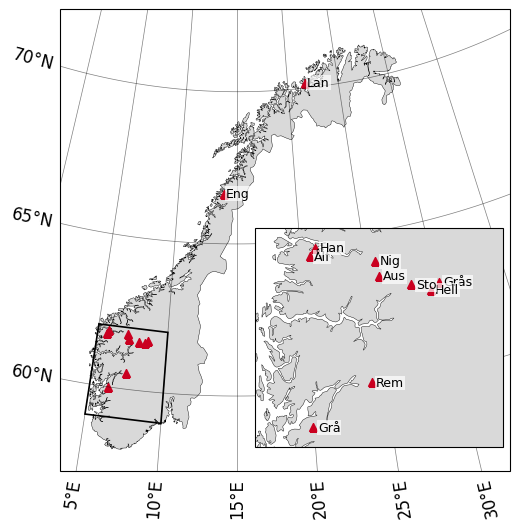

In [25]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import TransformedBbox, BboxPatch, BboxConnector
from matplotlib.patches import Rectangle


# Load Norway country boundary (Natural Earth shapefile)
norway = gpd.read_file(r"C:\Users\danis\Desktop\Danish\Norway Plot Data\ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp")
norway = norway[norway["ADMIN"] == "Norway"]

# Plot
projection = ccrs.EquidistantConic(
    central_longitude=15,
    central_latitude=65,
    standard_parallels=(60, 70)
)
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": projection})
ax.set_extent([4, 32, 57, 72])

# Plot country outline
norway.boundary.plot(ax=ax, edgecolor="black", linewidth=0.3, zorder=1, transform=ccrs.PlateCarree())
norway.plot(ax=ax, color="#d9d9d9", zorder=0, linewidth=0, transform=ccrs.PlateCarree())

# Add glaciers
ax.plot(glacier_lons, glacier_lats, marker='^', color='#ca0020', 
        linestyle='none', transform=ccrs.PlateCarree()) #ca0020

#  Add glacier labels
#for lon, lat, label in zip(glacier_lons, glacier_lats, glacier_labels):
    #ax.text(lon + 0.2, lat, label, fontsize=9, ha='left', va='center', transform=ccrs.PlateCarree())


#ax.coastlines(resolution='50m', linewidth=1)
#ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
gl= ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5)
gl.xlocator = mticker.FixedLocator(range(0, 40, 5))   # longitudes from 0 to 35 every 5°
gl.ylocator = mticker.FixedLocator(range(55, 75, 5)) 
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {"fontsize": 12}            # <- gridline label font sizes
gl.ylabel_style = {"fontsize": 12}

axins = inset_axes(ax, width="55%", height="55%", loc='lower right',
                   axes_class=GeoAxes, axes_kwargs=dict(projection=projection))

# Set zoomed extent for southern glaciers
axins.set_extent([5, 10, 60, 62], crs=ccrs.PlateCarree())

# Plot same country and glaciers again, but zoomed
norway.plot(ax=axins, color="#d9d9d9", edgecolor="black", linewidth=0.3, transform=ccrs.PlateCarree())
axins.plot(glacier_lons, glacier_lats, marker='^', color='#ca0020', linestyle='none', transform=ccrs.PlateCarree())

for lon, lat, label in zip(glacier_lons, glacier_lats, glacier_labels):
    if 5 <= lon <= 10 and 59 <= lat <= 62:
        axins.text(lon + 0.1, lat, label, fontsize=9, ha='left', va='center',
                   transform=ccrs.PlateCarree(),
                   bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5))

# Add labels for northern glaciers on the main map
for lon, lat, label in zip(glacier_lons, glacier_lats, glacier_labels):
    if lat > 65:  # condition to pick only the northern two
        ax.text(lon + 0.2, lat, label, fontsize=9, ha='left', va='center',
                transform=ccrs.PlateCarree(),
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5))


zoom_box = Rectangle((5, 59), 5, 3, linewidth=1.2,
                     edgecolor='black', facecolor='none',
                     linestyle='-', transform=ccrs.PlateCarree(), zorder=3)
ax.add_patch(zoom_box)

#plt.tight_layout()
#plt.savefig(r'C:\Users\danis\Desktop\Danish\Py-Plots\00- Thesis Plots\norway_glacier_locations.png', dpi=800, bbox_inches='tight')
plt.show()


### Trying to plot using netcdf file

In [1]:
import geopandas as gpd

norway = gpd.read_file(r"C:\Users\danis\Desktop\Danish\Norway Plot Data\ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp")
norway = norway[norway["ADMIN"] == "Norway"]

import xarray as xr

ds= xr.open_dataset(r"C:\Users\danis\Desktop\Danish\Norway Plot Data\gebco_2024\gebco_2024.nc")
print(ds.variables)
ds.info()

Frozen({'lon': <xarray.IndexVariable 'lon' (lon: 86400)> Size: 691kB
array([-179.997917, -179.99375 , -179.989583, ...,  179.989583,  179.99375 ,
        179.997917])
Attributes:
    standard_name:       longitude
    long_name:           longitude
    units:               degrees_east
    axis:                X
    sdn_parameter_urn:   SDN:P01::ALONZZ01
    sdn_parameter_name:  Longitude east
    sdn_uom_urn:         SDN:P06::DEGE
    sdn_uom_name:        Degrees east, 'lat': <xarray.IndexVariable 'lat' (lat: 43200)> Size: 346kB
array([-89.997917, -89.99375 , -89.989583, ...,  89.989583,  89.99375 ,
        89.997917])
Attributes:
    standard_name:       latitude
    long_name:           latitude
    units:               degrees_north
    axis:                Y
    sdn_parameter_urn:   SDN:P01::ALATZZ01
    sdn_parameter_name:  Latitude north
    sdn_uom_urn:         SDN:P06::DEGN
    sdn_uom_name:        Degrees north, 'crs': <xarray.Variable ()> Size: 1B
[1 values with dtype=|S1]
A

In [2]:
elevation = ds['elevation']

In [ ]:
bounds = norway.total_bounds  # [minx, miny, maxx, maxy]
elev = elevation.sel(lon=slice(bounds[0], bounds[2]), lat=slice(bounds[1], bounds[3]))
land_elev = elevation.where(elevation > 0)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})
lon2d, lat2d = np.meshgrid(land_elev.lon, land_elev.lat)
img = ax.pcolormesh(land_elev.lon, land_elev.lat, land_elev, cmap=plt.get_cmap("terrain"), transform=ccrs.PlateCarree())

ax.set_extent([bounds[0], bounds[2], bounds[1], bounds[3]])
ax.plot(glacier_lons, glacier_lats, marker='^', color='black', 
        linestyle='none', transform=ccrs.Mercator()) #ca0020
ax.coastlines()
ax.axis("off")

# Colorbar
cb = plt.colorbar(img, ax=ax, orientation="horizontal", shrink=0.5, pad=0.03)
cb.set_label("Elevation (m)")

plt.tight_layout()
plt.show()